In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Análisis Exploratorio de Datos

In [2]:
df = pd.read_csv("./Data/processed_agricultural_prices.csv")

In [3]:
df.head()

,semana,fecha_inicio,region,tipo_punto_monitoreo,producto,variedad,calidad,unidad,precio_minimo,precio_maximo,precio_promedio,anio,mes,producto_variedad,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum
0,1,2019-12-30,región_de_arica_y_parinacota,mercado_minorista,aceituna,amarga,extra,$/kilo,3500.0,4000.0,3750.0,2020,12,aceituna_amarga,23.4,26.78,20.7,0.62
1,1,2019-12-30,región_de_arica_y_parinacota,mercado_minorista,aceituna,amarga,primera,$/kilo,3000.0,3500.0,3250.0,2020,12,aceituna_amarga,23.4,26.78,20.7,0.62
2,1,2019-12-30,región_de_arica_y_parinacota,mercado_minorista,aceituna,amarga,segunda,$/kilo,2500.0,3000.0,2750.0,2020,12,aceituna_amarga,23.4,26.78,20.7,0.62
3,1,2019-12-30,región_de_arica_y_parinacota,mercado_minorista,aceituna,amarga,tercera,$/kilo,2000.0,2500.0,2250.0,2020,12,aceituna_amarga,23.4,26.78,20.7,0.62
4,1,2019-12-30,región_de_arica_y_parinacota,mercado_minorista,aceituna,negra,extra,$/kilo,3000.0,3500.0,3250.0,2020,12,aceituna_negra,23.4,26.78,20.7,0.62


In [4]:
%matplotlib inline

### Distribución de variables númericas

In [9]:
list(df.select_dtypes(include="number").columns)

['semana',
 'precio_minimo',
 'precio_maximo',
 'precio_promedio',
 'anio',
 'mes',
 'temperature_2m_mean',
 'temperature_2m_max',
 'temperature_2m_min',
 'precipitation_sum']

In [4]:
#Seleccionamos las variables númericas que hacen sentido revisar su distribución
numeric_cols = [
 'precio_minimo',
 'precio_maximo',
 'precio_promedio',
 'temperature_2m_mean',
 'temperature_2m_max',
 'temperature_2m_min',
 'precipitation_sum']
numeric_cols

['precio_minimo',
 'precio_maximo',
 'precio_promedio',
 'temperature_2m_mean',
 'temperature_2m_max',
 'temperature_2m_min',
 'precipitation_sum']

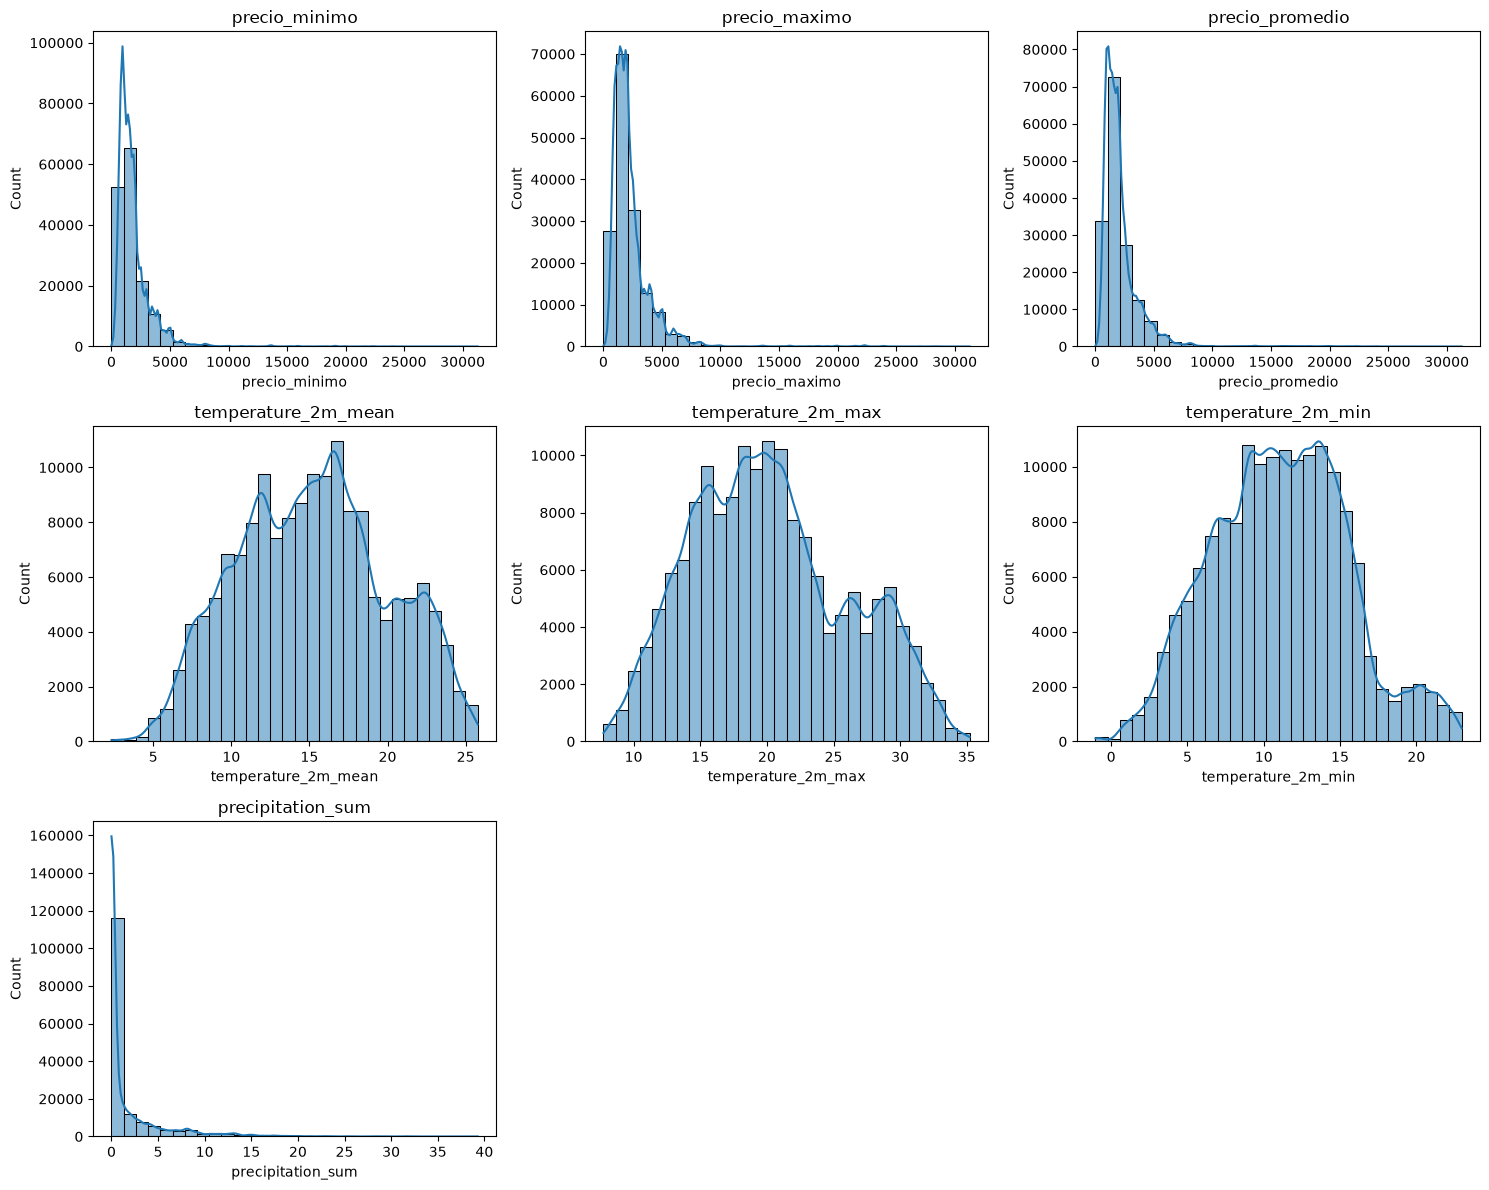

In [5]:
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(col)

# Eliminar ejes vacíos
for ax in axes[len(numeric_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### la columna precipitation_sum presenta una cola derecha bastante marcada, las columnas precio_promedio, precio_minimo y precio_maximo parecen tener una también pero falta ver más de cerca para estar seguro

### Al reducir el rango máximo del eje x se puede apreciar mejor la cola que los datos generan

<Axes: xlabel='precio_promedio', ylabel='Count'>

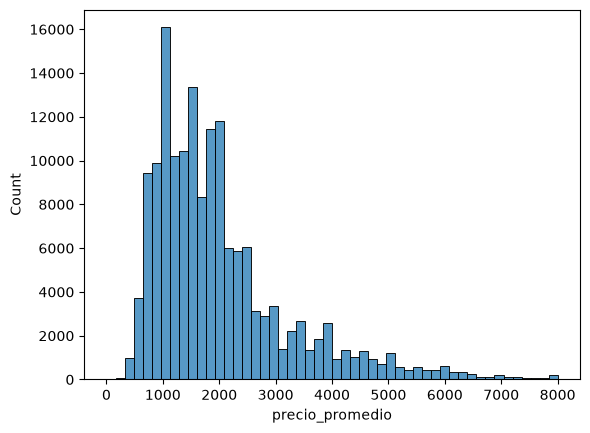

In [19]:
sns.histplot(df.precio_promedio[df.precio_promedio<=8000], bins=50)

### Aplicación de logaritmo a columnas que presentan cola derecha

In [6]:
col_precios = ['precio_promedio', 'precio_minimo', 'precio_maximo']

In [7]:
for col in col_precios:  
    df[col] = np.log(df[col])

In [8]:
#Como log(0) da un error y es perfectamente posible que precipitation_sum sea 0 en algunos casos; usaremos log1p() o log(1+x)
df.precipitation_sum = np.log1p(df.precipitation_sum)

<Axes: xlabel='precio_promedio', ylabel='Count'>

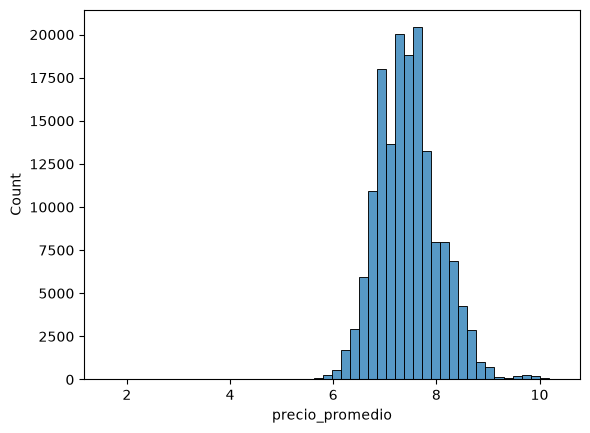

In [26]:
sns.histplot(df.precio_promedio, bins=50)

### Análisis de Outliers

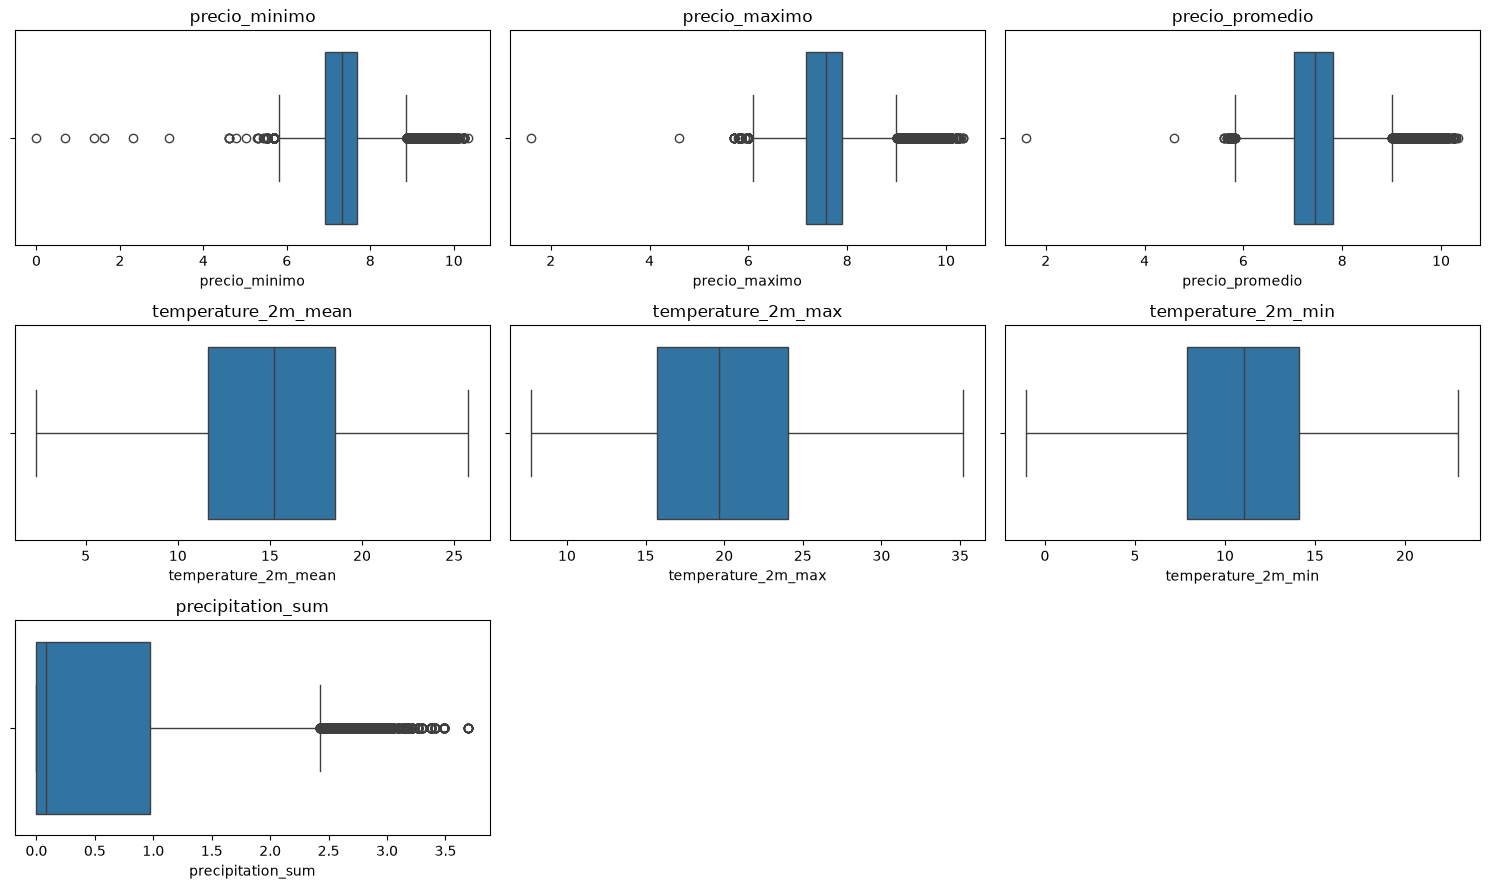

In [9]:
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

for ax in axes[len(numeric_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [10]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    mascara = (df[col] < limite_inferior) | (df[col] > limite_superior)

    print(f"{col}: {mascara.sum()} ({mascara.mean()*100:.2f}%)")

precio_minimo: 2190 (1.38%)
precio_maximo: 2020 (1.27%)
precio_promedio: 1421 (0.89%)
temperature_2m_mean: 0 (0.00%)
temperature_2m_max: 0 (0.00%)
temperature_2m_min: 0 (0.00%)
precipitation_sum: 6581 (4.13%)


In [11]:
df["precipitation_sum"].describe(percentiles=[0.90, 0.95, 0.99, 0.999])

count    159264.000000
mean          0.560118
std           0.805886
min           0.000000
90%           1.949983
95%           2.318177
99%           2.853181
99.9%         3.376612
max           3.695997
Name: precipitation_sum, dtype: float64

In [12]:
df[col_precios].describe()

,precio_promedio,precio_minimo,precio_maximo
count,159264.000000,159264.000000,159264.000000
mean,7.461045,7.330520,7.562236
std,0.592776,0.618915,0.586196
min,1.609438,0.000000,1.609438
25%,7.018402,6.907755,7.170120
50%,7.446001,7.313220,7.575585
75%,7.816820,7.691657,7.897296
max,10.350926,10.350926,10.350926


In [13]:
#un solo valor igual a 0 
df[df.precio_minimo ==0]

,semana,fecha_inicio,region,tipo_punto_monitoreo,producto,variedad,calidad,unidad,precio_minimo,precio_maximo,precio_promedio,anio,mes,producto_variedad,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum
88966,48,2023-11-27,región_del_biobío,feria_libre,damasco,castle_brite,primera,$/kilo,0.0,7.600902,7.17012,2023,11,damasco_castle_brite,13.442857,17.157143,10.242857,0.626702


In [14]:
df[df.producto_variedad =="damasco_castle_brite"]

,semana,fecha_inicio,region,tipo_punto_monitoreo,producto,variedad,calidad,unidad,precio_minimo,precio_maximo,precio_promedio,anio,mes,producto_variedad,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum
17898,49,2020-11-30,región_de_arica_y_parinacota,feria_libre,damasco,castle_brite,segunda,$/kilo,7.495542,7.600902,7.549609,2020,11,damasco_castle_brite,20.514286,23.928571,17.828571,0.000000
17926,49,2020-11-30,región_de_arica_y_parinacota,mercado_minorista,damasco,castle_brite,primera,$/kilo,7.600902,7.824046,7.718685,2020,11,damasco_castle_brite,20.514286,23.928571,17.828571,0.000000
17959,49,2020-11-30,región_de_coquimbo,feria_libre,damasco,castle_brite,primera,$/kilo,7.313220,7.495542,7.362011,2020,11,damasco_castle_brite,15.657143,19.371429,12.657143,0.000000
17960,49,2020-11-30,región_de_coquimbo,feria_libre,damasco,castle_brite,segunda,$/kilo,6.907755,6.907755,6.907755,2020,11,damasco_castle_brite,15.657143,19.371429,12.657143,0.000000
17994,49,2020-11-30,región_de_coquimbo,supermercado,damasco,castle_brite,primera,$/kilo,7.590852,7.859413,7.715570,2020,11,damasco_castle_brite,15.657143,19.371429,12.657143,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145977,51,2025-12-15,región_del_biobío,supermercado,damasco,castle_brite,primera,$/kilo,7.820038,7.820038,7.820038,2025,12,damasco_castle_brite,16.685714,20.842857,12.828571,1.093839
146029,51,2025-12-15,región_metropolitana,feria_libre,damasco,castle_brite,primera,$/kilo,7.090077,7.600902,7.332369,2025,12,damasco_castle_brite,20.742857,28.128571,14.114286,0.028171
146030,51,2025-12-15,región_metropolitana,feria_libre,damasco,castle_brite,segunda,$/kilo,6.684612,6.907755,6.802395,2025,12,damasco_castle_brite,20.742857,28.128571,14.114286,0.028171
146068,51,2025-12-15,región_metropolitana,supermercado,damasco,castle_brite,primera,$/kilo,8.213382,8.291547,8.230311,2025,12,damasco_castle_brite,20.742857,28.128571,14.114286,0.028171


In [39]:
df[ (df.producto_variedad =="damasco_castle_brite") & (df.semana == 48) & (df.region =="región_del_biobío")]

,semana,fecha_inicio,region,tipo_punto_monitoreo,producto,variedad,calidad,unidad,precio_minimo,precio_maximo,precio_promedio,anio,mes,producto_variedad,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum
88966,48,2023-11-27,región_del_biobío,feria_libre,damasco,castle_brite,primera,$/kilo,0.000000,7.600902,7.170120,2023,11,damasco_castle_brite,13.442857,17.157143,10.242857,0.626702
88967,48,2023-11-27,región_del_biobío,feria_libre,damasco,castle_brite,segunda,$/kilo,7.090077,7.313220,7.244228,2023,11,damasco_castle_brite,13.442857,17.157143,10.242857,0.626702
89000,48,2023-11-27,región_del_biobío,supermercado,damasco,castle_brite,primera,$/kilo,7.859413,7.897296,7.884953,2023,11,damasco_castle_brite,13.442857,17.157143,10.242857,0.626702
117621,48,2024-11-25,región_del_biobío,feria_libre,damasco,castle_brite,primera,$/kilo,7.313220,7.313220,7.313220,2024,11,damasco_castle_brite,14.514286,18.142857,10.571429,0.194156
144223,48,2025-11-24,región_del_biobío,supermercado,damasco,castle_brite,primera,$/kilo,8.291547,8.291547,8.291547,2025,11,damasco_castle_brite,15.028571,18.485714,12.471429,0.538997


### Tras revisar la posibilidad de que el precio_minimo simplemente no haya sido ingresado, haber calculado el valor y comprobar que el resultado sea coherente con el resto de entradas para esa fruta,epoca del año y región; el valor fue corregido

#### Cálculo simple:

In [15]:
# (min+max)/2 = promedio
# min + max = (promedio*2)
# min = (promedio*2) - max
max_ = 7.600902
prom = 7.170120
min_= (prom *2) - max_
min_

6.739338

In [16]:
(min_ + max_)/2

7.17012

In [17]:
df.at[88966, "precio_minimo"] = min_

In [18]:
df.iloc[88966].precio_minimo

np.float64(6.739338)

In [19]:
df[col_precios].describe()

,precio_promedio,precio_minimo,precio_maximo
count,159264.000000,159264.000000,159264.000000
mean,7.461045,7.330562,7.562236
std,0.592776,0.618645,0.586196
min,1.609438,0.693147,1.609438
25%,7.018402,6.907755,7.170120
50%,7.446001,7.313220,7.575585
75%,7.816820,7.691657,7.897296
max,10.350926,10.350926,10.350926


In [20]:
Q1 = df["precio_promedio"].quantile(0.25)
Q3 = df["precio_promedio"].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = df[
    (df["precio_promedio"] < lim_inf) | 
    (df["precio_promedio"] > lim_sup)
]

outliers

,semana,fecha_inicio,region,tipo_punto_monitoreo,producto,variedad,calidad,unidad,precio_minimo,precio_maximo,precio_promedio,anio,mes,producto_variedad,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum
347,2,2020-01-06,región_de_arica_y_parinacota,feria_libre,arándano,blue,segunda,$/kilo,9.210340,9.210340,9.210340,2020,1,arándano_blue,23.471429,27.142857,20.585714,0.028171
383,2,2020-01-06,región_de_arica_y_parinacota,mercado_minorista,arándano,blue,segunda,$/kilo,9.210340,9.210340,9.210340,2020,1,arándano_blue,23.471429,27.142857,20.585714,0.028171
799,2,2020-01-06,región_metropolitana,supermercado,arándano,blue,primera,$/kilo,8.364042,9.385973,9.067047,2020,1,arándano_blue,21.400000,29.542857,14.700000,0.000000
805,2,2020-01-06,región_metropolitana,supermercado,frambuesa,NaN,primera,$/kilo,9.675331,9.724361,9.700147,2020,1,frambuesa,21.400000,29.542857,14.700000,0.000000
861,3,2020-01-13,región_de_arica_y_parinacota,mercado_minorista,arándano,blue,segunda,$/kilo,9.210340,9.210340,9.210340,2020,1,arándano_blue,23.671429,26.628571,21.314286,0.217413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159099,27,2026-06-29,región_de_valparaíso,supermercado,frutilla,NaN,primera,$/kilo,9.207035,9.207035,9.207035,2026,6,frutilla,10.166667,13.733333,7.500000,0.000000
159192,27,2026-06-29,región_metropolitana,feria_libre,limón,amarillo,segunda,$/kilo,5.521461,6.396930,5.808142,2026,6,limón_amarillo,8.333333,14.533333,4.000000,0.000000
159193,27,2026-06-29,región_metropolitana,feria_libre,limón,plateado,segunda,$/kilo,5.521461,5.991465,5.703782,2026,6,limón_plateado,8.333333,14.533333,4.000000,0.000000
159226,27,2026-06-29,región_metropolitana,supermercado,arándano,blue,primera,$/kilo,9.520249,9.858490,9.703633,2026,6,arándano_blue,8.333333,14.533333,4.000000,0.000000


In [21]:
outliers.describe()

,semana,precio_minimo,precio_maximo,precio_promedio,anio,mes,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum
count,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000
mean,24.239268,9.099683,9.267478,9.199246,2023.934553,5.991555,16.362528,22.230904,11.728266,0.424667
std,15.805300,1.120617,1.107210,1.109647,1.713022,3.650960,4.774057,5.826060,4.359340,0.701167
min,1.000000,1.609438,1.609438,1.609438,2020.000000,1.000000,4.242857,8.442857,0.757143,0.000000
25%,10.000000,9.024011,9.101306,9.063347,2023.000000,3.000000,12.414286,17.557143,8.842857,0.000000
50%,22.000000,9.316501,9.532424,9.516132,2024.000000,5.000000,16.385714,21.985714,11.528571,0.028171
75%,39.000000,9.675331,9.899480,9.798127,2025.000000,9.000000,20.585714,27.342857,15.014286,0.603535
max,52.000000,10.350926,10.350926,10.350926,2026.000000,12.000000,25.771429,34.442857,22.971429,3.483435


<Axes: xlabel='count', ylabel='producto_variedad'>

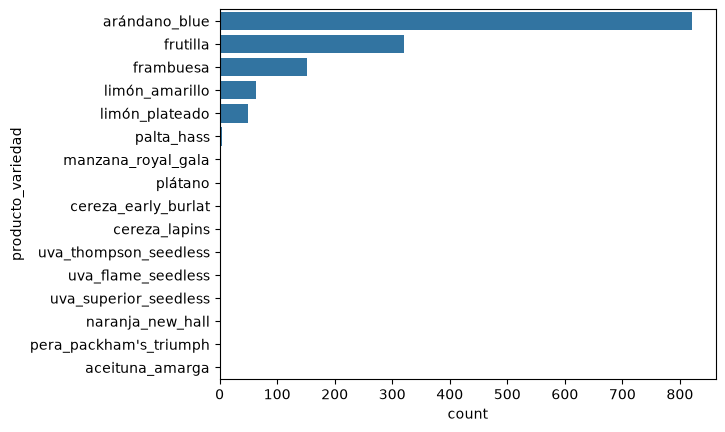

In [22]:
sns.countplot(
    data=outliers,
    y="producto_variedad",
    order=outliers["producto_variedad"].value_counts().index
)

#### Observación: La gran mayoria de los outliers se trata de frutas conocidad por sus valores particularme altos como lo son los arándanos

In [23]:
#Conteo de las 3 frutas que conforman la mayoria de los outliers
count= (len(outliers[outliers.producto_variedad =="arándano_blue"]) + 
        len(outliers[outliers.producto_variedad =="frutilla"])+
        len(outliers[outliers.producto_variedad =="frambuesa"]))
count

1293

In [103]:
df.precipitation_sum.describe()

count    159264.000000
mean          0.560118
std           0.805886
min           0.000000
25%           0.000000
50%           0.082238
75%           0.971861
max           3.695997
Name: precipitation_sum, dtype: float64

In [24]:
Q1 = df["precipitation_sum"].quantile(0.25)
Q3 = df["precipitation_sum"].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_inf =  df[df["precipitation_sum"] < lim_inf]
outliers_sup =  df[df["precipitation_sum"] > lim_sup]




In [25]:
outliers_inf

,semana,fecha_inicio,region,tipo_punto_monitoreo,producto,variedad,calidad,unidad,precio_minimo,precio_maximo,precio_promedio,anio,mes,producto_variedad,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum


In [26]:
#Todos los outliers sobrepasan el limite superior
outliers_sup

,semana,fecha_inicio,region,tipo_punto_monitoreo,producto,variedad,calidad,unidad,precio_minimo,precio_maximo,precio_promedio,anio,mes,producto_variedad,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum
7197,16,2020-04-13,región_de_los_lagos,feria_libre,arándano,blue,primera,$/kilo,7.824046,7.824046,7.824046,2020,4,arándano_blue,13.528571,16.128571,10.814286,2.515390
7198,16,2020-04-13,región_de_los_lagos,feria_libre,frutilla,NaN,primera,$/kilo,7.600902,7.600902,7.600902,2020,4,frutilla,13.528571,16.128571,10.814286,2.515390
7199,16,2020-04-13,región_de_los_lagos,feria_libre,kiwi,hayward,primera,$/kilo,7.313220,7.313220,7.313220,2020,4,kiwi_hayward,13.528571,16.128571,10.814286,2.515390
7200,16,2020-04-13,región_de_los_lagos,feria_libre,limón,amarillo,primera,$/kilo,7.824046,7.824046,7.824046,2020,4,limón_amarillo,13.528571,16.128571,10.814286,2.515390
7201,16,2020-04-13,región_de_los_lagos,feria_libre,limón,plateado,primera,$/kilo,7.600902,7.901007,7.762171,2020,4,limón_plateado,13.528571,16.128571,10.814286,2.515390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154894,19,2026-05-04,región_de_los_lagos,supermercado,plátano,NaN,primera,$/kilo,7.207860,7.371489,7.317876,2026,5,plátano,8.685714,11.328571,6.171429,2.471725
154895,19,2026-05-04,región_de_los_lagos,supermercado,tuna,NaN,primera,$/kilo,8.098643,8.098643,8.098643,2026,5,tuna,8.685714,11.328571,6.171429,2.471725
154896,19,2026-05-04,región_de_los_lagos,supermercado,uva,red_globe,primera,$/kilo,8.409608,8.552560,8.483636,2026,5,uva_red_globe,8.685714,11.328571,6.171429,2.471725
154897,19,2026-05-04,región_de_los_lagos,supermercado,uva,superior_seedless,primera,$/kilo,8.291547,8.409608,8.352319,2026,5,uva_superior_seedless,8.685714,11.328571,6.171429,2.471725


In [27]:
outliers_sup[outliers_sup["temperature_2m_mean"]>=14] # con 15 ya no hay valores

,semana,fecha_inicio,region,tipo_punto_monitoreo,producto,variedad,calidad,unidad,precio_minimo,precio_maximo,precio_promedio,anio,mes,producto_variedad,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum
125550,10,2025-03-03,región_de_los_lagos,feria_libre,arándano,blue,primera,$/kilo,8.160518,8.160518,8.160518,2025,3,arándano_blue,14.100000,17.771429,10.014286,2.439859
125551,10,2025-03-03,región_de_los_lagos,feria_libre,frutilla,NaN,primera,$/kilo,8.006368,8.160518,8.086410,2025,3,frutilla,14.100000,17.771429,10.014286,2.439859
125552,10,2025-03-03,región_de_los_lagos,feria_libre,limón,amarillo,primera,$/kilo,7.600902,7.824046,7.718685,2025,3,limón_amarillo,14.100000,17.771429,10.014286,2.439859
125553,10,2025-03-03,región_de_los_lagos,feria_libre,limón,plateado,primera,$/kilo,7.824046,8.006368,7.919356,2025,3,limón_plateado,14.100000,17.771429,10.014286,2.439859
125554,10,2025-03-03,región_de_los_lagos,feria_libre,limón,plateado,segunda,$/kilo,7.600902,7.600902,7.600902,2025,3,limón_plateado,14.100000,17.771429,10.014286,2.439859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151815,12,2026-03-16,región_de_ñuble,supermercado,uva,flame_seedless,segunda,$/kilo,7.237059,7.237059,7.237059,2026,3,uva_flame_seedless,14.271429,19.800000,10.285714,2.466888
151816,12,2026-03-16,región_de_ñuble,supermercado,uva,superior_seedless,primera,$/kilo,8.064636,8.515191,8.299037,2026,3,uva_superior_seedless,14.271429,19.800000,10.285714,2.466888
151817,12,2026-03-16,región_de_ñuble,supermercado,uva,superior_seedless,segunda,$/kilo,7.237059,7.237059,7.237059,2026,3,uva_superior_seedless,14.271429,19.800000,10.285714,2.466888
151818,12,2026-03-16,región_de_ñuble,supermercado,uva,thompson_seedless,primera,$/kilo,8.064636,8.515191,8.299037,2026,3,uva_thompson_seedless,14.271429,19.800000,10.285714,2.466888


In [28]:
#Semanas que conforman el verano
verano = [48, 49, 50, 51, 52, 1, 2, 3, 4, 5, 6, 7, 8, 9]

outliers_verano = outliers_sup[
    outliers_sup["semana"].isin(verano)
]

In [29]:
outliers_verano

,semana,fecha_inicio,region,tipo_punto_monitoreo,producto,variedad,calidad,unidad,precio_minimo,precio_maximo,precio_promedio,anio,mes,producto_variedad,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum


## Conclusion sobre outliers:

### Los valores atípicos fueron identificados mediante el método del IQR. 
### De los 1421 outliers para los campos de precio, 1293 (91%) se trata de frutas cuyo valor alto no resulta una sorpresa ( arandanos,frambuesas y frutillas). Además de tratarse de valores perfectamente plausibles.
### Todos los outliers del campo **precipitation_sum**  fueron outliers del limite superior, o sea lluvias elevadas; de estos outliers ningún valor es imposible y ningún valor fue registrado durante el verano o con temperaturas medias altas, lo que habría levantado sospecha

### Tras inspeccionar los registros, no se encontraron valores imposibles ni inconsistencias evidentes. Los outliers observados en las variables de precio y precipitación corresponden a eventos plausibles dentro del dominio del problema (variaciones estacionales, diferencias entre productos y episodios meteorológicos), por lo que se decidió conservarlos para el modelado.

# Feature importance y matriz de correlación

In [30]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

In [31]:
list(df.dtypes.index)

['semana',
 'fecha_inicio',
 'region',
 'tipo_punto_monitoreo',
 'producto',
 'variedad',
 'calidad',
 'unidad',
 'precio_minimo',
 'precio_maximo',
 'precio_promedio',
 'anio',
 'mes',
 'producto_variedad',
 'temperature_2m_mean',
 'temperature_2m_max',
 'temperature_2m_min',
 'precipitation_sum']

In [32]:
#Seleccionamos todas las variables que usaremos. notese que fecha_inicio nos entrega la misma informacion que anio,mes,semana
# y que precio_minimo y precio_maximo son variables que calcular la variable objetivo por lo que estas seran retiradas para trabajar el modelo
X = df[
    [
        "semana",
        "region",
        "tipo_punto_monitoreo",
        "producto_variedad",
        "calidad",
        "anio",
        "mes",
        'temperature_2m_mean',
         "temperature_2m_max",
         "temperature_2m_min",
         "precipitation_sum"
    ]
]

y = df["precio_promedio"]

In [33]:
X_encoded = X.copy()

for col in X_encoded.select_dtypes("str"):
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])

### Información Mutua

In [34]:
mi = mutual_info_regression(
    X_encoded,
    y
)

pd.Series(
    mi,
    index=X_encoded.columns
).sort_values(ascending=False)

producto_variedad       0.664527
tipo_punto_monitoreo    0.492779
region                  0.276185
temperature_2m_max      0.250312
temperature_2m_mean     0.245442
temperature_2m_min      0.243984
calidad                 0.156286
anio                    0.123185
precipitation_sum       0.121056
semana                  0.081462
mes                     0.069895
dtype: float64

### Correlación

In [35]:
numerical_col = list(df.dtypes[(df.dtypes =="int64") | (df.dtypes =="float64")].index)
numerical_col

['semana',
 'precio_minimo',
 'precio_maximo',
 'precio_promedio',
 'anio',
 'mes',
 'temperature_2m_mean',
 'temperature_2m_max',
 'temperature_2m_min',
 'precipitation_sum']

In [36]:
#Removemos las variables que son o describen la variabler predictoria
numerical_col.remove("precio_minimo")
numerical_col.remove("precio_maximo")
numerical_col.remove("precio_promedio")

In [37]:
df[numerical_col].corrwith(df.precio_promedio).abs().sort_values(ascending=False)

anio                   0.205913
temperature_2m_min     0.138296
temperature_2m_mean    0.127833
temperature_2m_max     0.104709
semana                 0.048538
mes                    0.046744
precipitation_sum      0.036566
dtype: float64

In [39]:
corr = df[numerical_col].corr()

In [40]:
corr

,semana,anio,mes,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum
semana,1.000000,-0.095655,0.956595,-0.293730,-0.272119,-0.301539,0.076423
anio,-0.095655,1.000000,-0.086314,0.037443,0.054208,0.016787,0.015069
mes,0.956595,-0.086314,1.000000,-0.269213,-0.247155,-0.280467,0.062208
temperature_2m_mean,-0.293730,0.037443,-0.269213,1.000000,0.944209,0.941029,-0.570595
temperature_2m_max,-0.272119,0.054208,-0.247155,0.944209,1.000000,0.782901,-0.577642
temperature_2m_min,-0.301539,0.016787,-0.280467,0.941029,0.782901,1.000000,-0.507959
precipitation_sum,0.076423,0.015069,0.062208,-0.570595,-0.577642,-0.507959,1.000000


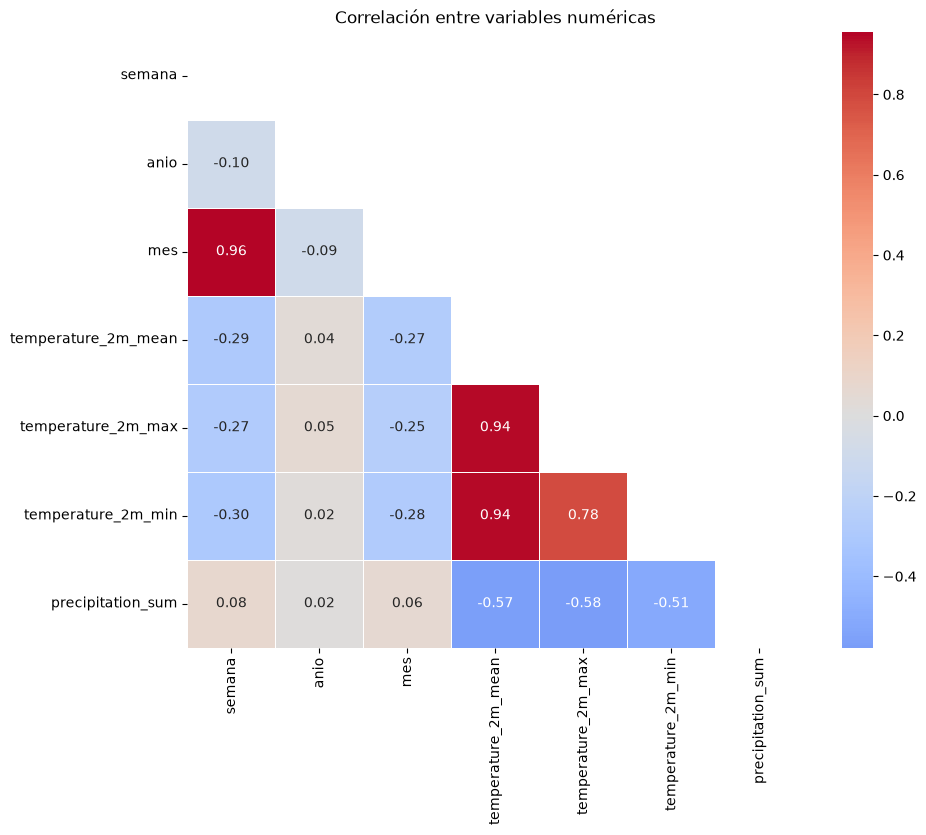

In [43]:
corr = df[numerical_col].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=.5
)

plt.title("Correlación entre variables numéricas")
plt.show()

# Conclusiones

# Conclusiones

El análisis exploratorio permitió comprender la estructura del conjunto de datos, identificar posibles problemas de calidad y evaluar la relación entre las variables disponibles y la variable objetivo (`precio_promedio`). En términos generales, el dataset presenta una calidad adecuada para continuar con la etapa de modelado, sin evidenciar inconsistencias que comprometan el entrenamiento de un modelo predictivo.

## Hallazgos principales

- Se verificó la calidad de los datos, descartando valores faltantes e inconsistencias relevantes que requirieran un tratamiento adicional.
- Las variables de precio presentan distribuciones asimétricas, por lo que se evaluó la aplicación de una transformación logarítmica para reducir el sesgo. Dicha transformación será incorporada durante la etapa de preprocesamiento del modelo y no modifica el conjunto de datos utilizado en este análisis.
- El análisis de valores atípicos mostró que estos corresponden al comportamiento natural del mercado y no a errores de captura, por lo que se decidió conservarlos.
- El análisis de información mutua y correlación permitió identificar las variables con mayor capacidad explicativa respecto a la variable objetivo, sirviendo como referencia para la selección de características durante el entrenamiento.
- La matriz de correlación evidenció una fuerte relación entre las distintas variables de temperatura, así como entre las variables temporales `semana` y `mes`, indicando la existencia de información redundante entre algunos predictores.
- No se identificaron correlaciones inesperadas que sugieran errores en la integración de las distintas fuentes de datos.

## Decisiones para la etapa de entrenamiento

A partir de los resultados obtenidos durante el análisis exploratorio, se adoptarán las siguientes decisiones para el desarrollo de los modelos predictivos:

- Aplicar la transformación logarítmica únicamente durante el preprocesamiento del modelo.
- Estandarizar las variables numéricas cuando el algoritmo de aprendizaje lo requiera.
- Excluir variables que puedan generar fuga de información hacia la variable objetivo,o sea; quedarnos solo con precio_promedio.
- Evaluar el impacto de las variables altamente correlacionadas sobre el desempeño de distintos modelos, especialmente aquellos sensibles a la multicolinealidad.
- Comparar múltiples algoritmos de regresión utilizando un mismo flujo de preprocesamiento para seleccionar el modelo con mejor capacidad predictiva.

## Próxima etapa

Finalizado el análisis exploratorio, la siguiente fase consistirá en construir el pipeline de entrenamiento, incluyendo el preprocesamiento definido en este notebook, la división entre conjuntos de entrenamiento y prueba, el entrenamiento de distintos modelos de regresión y la evaluación de su desempeño mediante métricas apropiadas.